In [1]:
!pip install transformers datasets einops matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.amp import autocast, GradScaler

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

In [5]:
baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [7]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

In [8]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_dataset.set_format("torch")

In [9]:
train_loader = DataLoader(
    tokenized_dataset["train"].select(range(2000)),
    batch_size=16
)

eval_loader = DataLoader(
    tokenized_dataset["validation"].select(range(500)),
    batch_size=16
)

In [10]:
def evaluate_perplexity(model, loader):

    model.eval()

    total_loss = 0
    steps = 0

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            steps += 1

    return math.exp(total_loss / steps)

In [11]:
baseline_params = count_parameters(baseline_model)

start = time.time()
baseline_ppl = evaluate_perplexity(baseline_model, eval_loader)
baseline_inference_time = time.time() - start

print("Baseline Params:", baseline_params)
print("Baseline PPL:", baseline_ppl)
print("Baseline Inference Time:", baseline_inference_time)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Baseline Params: 124439808
Baseline PPL: 60.27171013912783
Baseline Inference Time: 4.7201433181762695


In [12]:
def kronecker_rank_r(W, m1, m2, n1, n2, rank):

    W = W.reshape(m1, m2, n1, n2)
    W = W.permute(0,2,1,3).reshape(m1*n1, m2*n2)

    U,S,Vh = torch.linalg.svd(W, full_matrices=False)

    A_list = []
    B_list = []

    for r in range(rank):

        u = U[:,r]
        v = Vh[r,:]
        s = S[r]

        A = (u*math.sqrt(s)).reshape(m1,n1)
        B = (v*math.sqrt(s)).reshape(m2,n2)

        A_list.append(A.to(device))
        B_list.append(B.to(device))

    return A_list,B_list

In [13]:
class KronLinear(nn.Module):

    def __init__(self, A_list, B_list, bias):

        super().__init__()

        self.A_list = nn.ParameterList([nn.Parameter(A) for A in A_list])
        self.B_list = nn.ParameterList([nn.Parameter(B) for B in B_list])

        self.bias = nn.Parameter(bias.clone())

    def forward(self,x):

        out = 0

        for A,B in zip(self.A_list,self.B_list):

            W = torch.kron(A,B)

            out += torch.matmul(x,W.t())

        return out + self.bias

In [14]:
def compress_layer_axb(model,layer_idx,rank):

    block = model.transformer.h[layer_idx]

    W_fc = block.mlp.c_fc.weight.data.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A,B = kronecker_rank_r(W_fc,48,64,12,64,rank)

    block.mlp.c_fc = KronLinear(A,B,b_fc)

    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A,B = kronecker_rank_r(W_proj,12,64,48,64,rank)

    block.mlp.c_proj = KronLinear(A,B,b_proj)

In [15]:
def build_axb_model(rank):

    model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    for i in range(12):
        compress_layer_axb(model,i,rank)

    model.eval()

    return model

In [16]:
def kronecker_abc(W,m1,m2,m3,n1,n2,n3):

    W = W.reshape(m1,m2,m3,n1,n2,n3)
    W = W.permute(0,3,1,4,2,5).reshape(m1*n1,m2*n2*m3*n3)

    U,S,Vh = torch.linalg.svd(W,full_matrices=False)

    u = U[:,0]
    v = Vh[0,:]
    s = S[0]

    A = (u*math.sqrt(s)).reshape(m1,n1)

    B = torch.randn(m2,n2).to(device)
    C = torch.randn(m3,n3).to(device)

    return A,B,C

In [17]:
class KronABCLinear(nn.Module):

    def __init__(self,A,B,C,bias):

        super().__init__()

        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.C = nn.Parameter(C)

        self.bias = nn.Parameter(bias)

    def forward(self,x):

        W = torch.kron(torch.kron(self.A,self.B),self.C)

        return torch.matmul(x,W.t()) + self.bias

In [18]:
def compress_layer_abc(model,layer_idx):

    block = model.transformer.h[layer_idx]

    W_fc = block.mlp.c_fc.weight.data.T.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A,B,C = kronecker_abc(W_fc,3,16,64,3,16,16)

    block.mlp.c_fc = KronABCLinear(A,B,C,b_fc)

    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A,B,C = kronecker_abc(W_proj,3,16,16,3,16,64)

    block.mlp.c_proj = KronABCLinear(A,B,C,b_proj)

In [19]:
def build_abc_model():

    model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    for i in range(12):
        compress_layer_abc(model,i)

    model.eval()

    return model

In [20]:
ranks = [1,2,4]

In [21]:
axb_results = []

for r in ranks:

    start = time.time()

    model = build_axb_model(r)

    compression_time = time.time() - start

    start = time.time()
    ppl = evaluate_perplexity(model,eval_loader)
    inference_time = time.time() - start

    params = count_parameters(model)

    axb_results.append((r,params,ppl,compression_time,inference_time))

In [22]:
start = time.time()

abc_model = build_abc_model()

abc_compression_time = time.time()-start

start = time.time()
abc_ppl = evaluate_perplexity(abc_model,eval_loader)
abc_inference_time = time.time()-start

abc_params = count_parameters(abc_model)

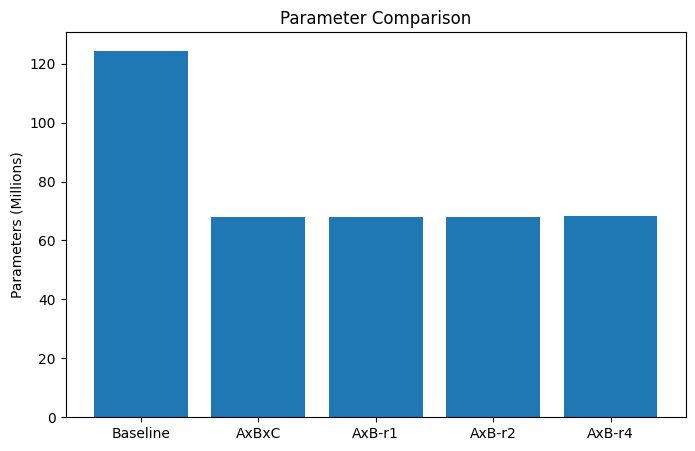

In [23]:
plt.figure(figsize=(8,5))

models = ["Baseline","AxBxC"]
params = [baseline_params,abc_params]

for r,p,_,_,_ in axb_results:
    models.append(f"AxB-r{r}")
    params.append(p)

plt.bar(models,[p/1e6 for p in params])

plt.ylabel("Parameters (Millions)")
plt.title("Parameter Comparison")

plt.show()

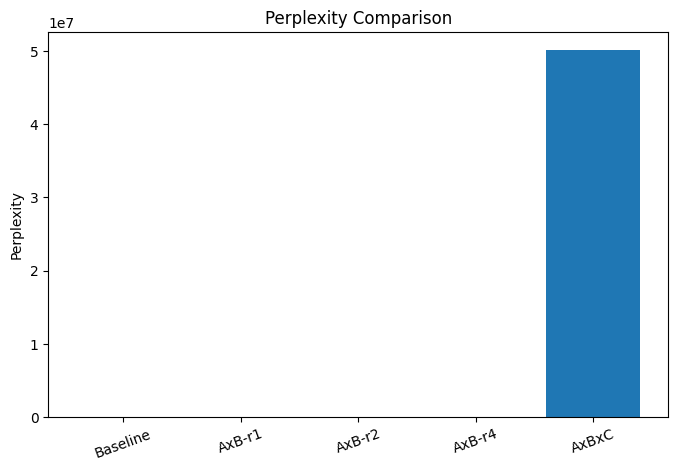

In [24]:
plt.figure(figsize=(8,5))

models = ["Baseline"]
ppls = [baseline_ppl]

for r,_,p,_,_ in axb_results:
    models.append(f"AxB-r{r}")
    ppls.append(p)

models.append("AxBxC")
ppls.append(abc_ppl)

plt.bar(models,ppls)

plt.ylabel("Perplexity")
plt.title("Perplexity Comparison")

plt.xticks(rotation=20)

plt.show()

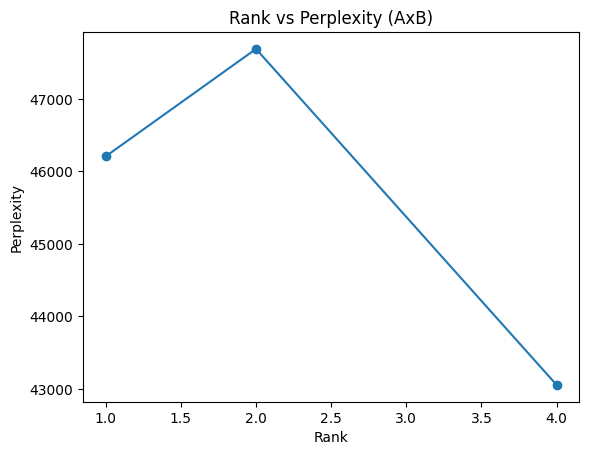

In [25]:
r = [x[0] for x in axb_results]
p = [x[2] for x in axb_results]

plt.plot(r,p,marker="o")

plt.xlabel("Rank")
plt.ylabel("Perplexity")

plt.title("Rank vs Perplexity (AxB)")

plt.show()

In [26]:
layer_errors = []

for layer in range(12):

    model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    compress_layer_axb(model,layer,1)

    ppl = evaluate_perplexity(model,eval_loader)

    layer_errors.append(ppl)

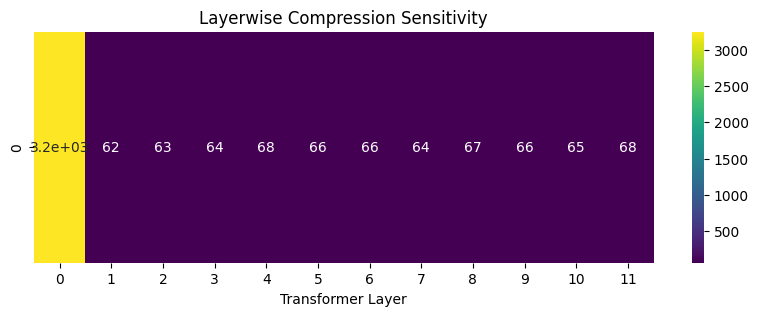

In [27]:
plt.figure(figsize=(10,3))

sns.heatmap([layer_errors],annot=True,cmap="viridis")

plt.title("Layerwise Compression Sensitivity")

plt.xlabel("Transformer Layer")

plt.show()

In [28]:
cumulative_ppl = []

for L in range(1,13):

    model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    for i in range(L):
        compress_layer_axb(model,i,1)

    ppl = evaluate_perplexity(model,eval_loader)

    cumulative_ppl.append(ppl)

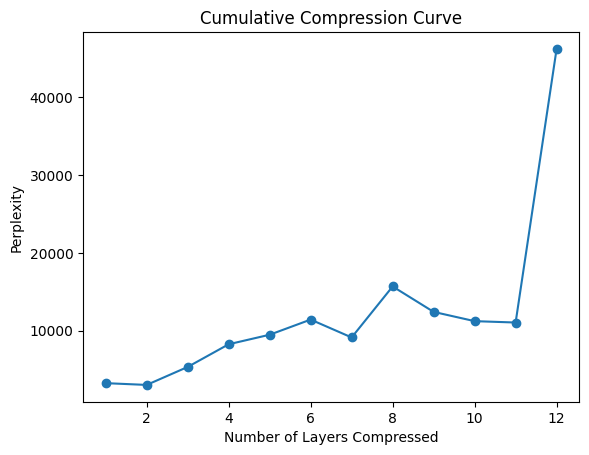

In [29]:
plt.plot(range(1,13),cumulative_ppl,marker="o")

plt.xlabel("Number of Layers Compressed")

plt.ylabel("Perplexity")

plt.title("Cumulative Compression Curve")

plt.show()

In [30]:
def retrain_model(model, train_loader, epochs=5, lr=3e-5):

    optimizer = AdamW(model.parameters(), lr=lr)

    scaler = GradScaler("cuda")

    model.train()

    loss_history = []

    start_time = time.time()

    for epoch in range(epochs):

        total_loss = 0
        steps = 0

        for batch in train_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            optimizer.zero_grad()

            with autocast("cuda"):

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            steps += 1

        avg_loss = total_loss / steps

        loss_history.append(avg_loss)

        print("Epoch", epoch+1, "Loss:", avg_loss)

    training_time = time.time() - start_time

    return loss_history, training_time

In [31]:
axb_model = build_axb_model(rank=1)

print("Retraining AxB model")

axb_loss, axb_training_time = retrain_model(axb_model, train_loader)

print("AxB training time:", axb_training_time)

Retraining AxB model
Epoch 1 Loss: 7.952212589263916
Epoch 2 Loss: 7.137880821228027
Epoch 3 Loss: 6.880597579956055
Epoch 4 Loss: 6.690858806610107
Epoch 5 Loss: 6.517923591613769
AxB training time: 529.8810880184174


In [32]:
abc_model = build_abc_model()

print("Retraining AxBxC model")

abc_loss, abc_training_time = retrain_model(abc_model, train_loader)

print("AxBxC training time:", abc_training_time)

Retraining AxBxC model
Epoch 1 Loss: 13.820513061523437
Epoch 2 Loss: 10.446418441772462
Epoch 3 Loss: 9.32566106414795
Epoch 4 Loss: 8.753175136566162
Epoch 5 Loss: 8.351153392791748
AxBxC training time: 552.4308145046234


In [33]:
axb_ppl_after = evaluate_perplexity(axb_model, eval_loader)

abc_ppl_after = evaluate_perplexity(abc_model, eval_loader)

print("AxB PPL after training:", axb_ppl_after)
print("AxBxC PPL after training:", abc_ppl_after)

AxB PPL after training: 1059.8831723820454
AxBxC PPL after training: 3875.174775723276


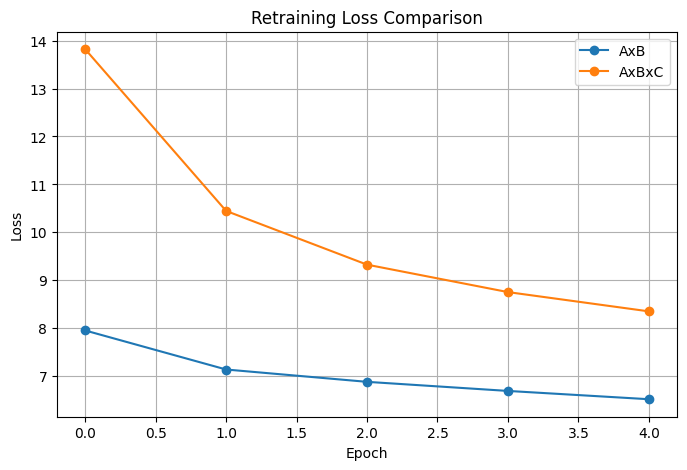

In [34]:
plt.figure(figsize=(8,5))

plt.plot(axb_loss, marker="o", label="AxB")
plt.plot(abc_loss, marker="o", label="AxBxC")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Retraining Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

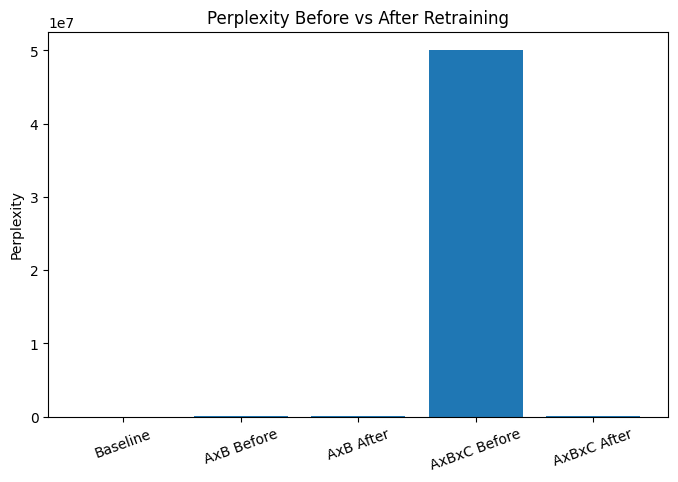

In [35]:
models = [
    "Baseline",
    "AxB Before",
    "AxB After",
    "AxBxC Before",
    "AxBxC After"
]

values = [
    baseline_ppl,
    axb_results[0][2],
    axb_ppl_after,
    abc_ppl,
    abc_ppl_after
]

plt.figure(figsize=(8,5))

plt.bar(models, values)

plt.ylabel("Perplexity")

plt.title("Perplexity Before vs After Retraining")

plt.xticks(rotation=20)

plt.show()

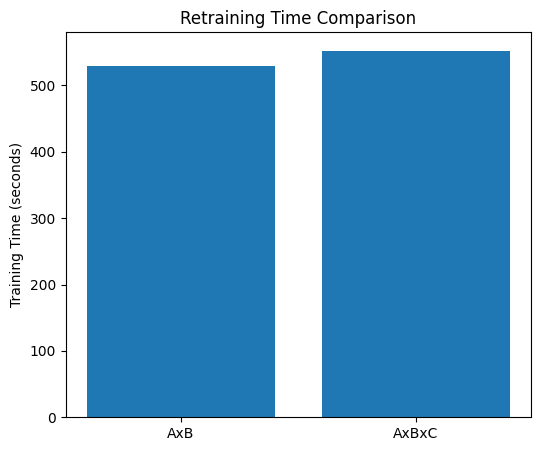

In [36]:
plt.figure(figsize=(6,5))

plt.bar(
    ["AxB", "AxBxC"],
    [axb_training_time, abc_training_time]
)

plt.ylabel("Training Time (seconds)")

plt.title("Retraining Time Comparison")

plt.show()

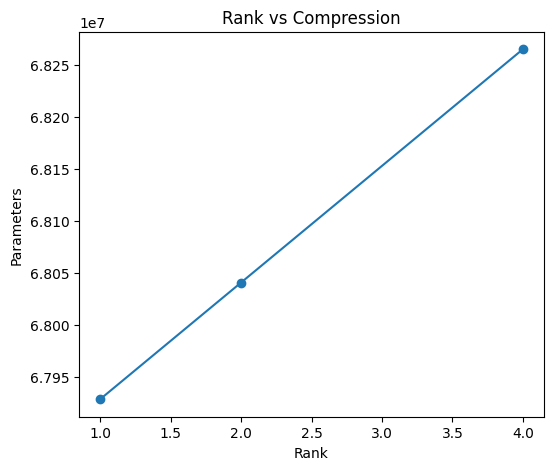

In [37]:
plt.figure(figsize=(6,5))

ranks = [x[0] for x in axb_results]
params = [x[1] for x in axb_results]

plt.plot(ranks, params, marker="o")

plt.xlabel("Rank")
plt.ylabel("Parameters")

plt.title("Rank vs Compression")

plt.show()

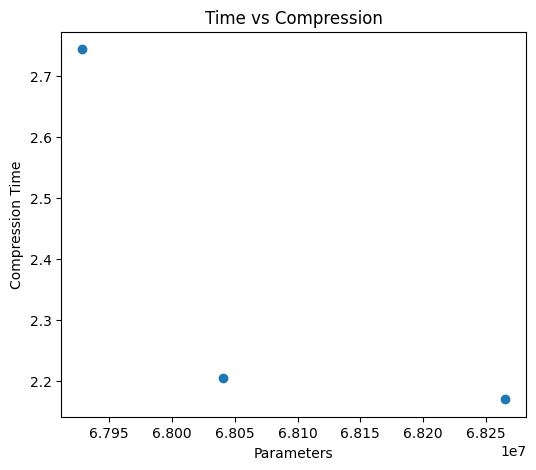

In [38]:
plt.figure(figsize=(6,5))

times = [x[3] for x in axb_results]
params = [x[1] for x in axb_results]

plt.scatter(params, times)

plt.xlabel("Parameters")
plt.ylabel("Compression Time")

plt.title("Time vs Compression")

plt.show()

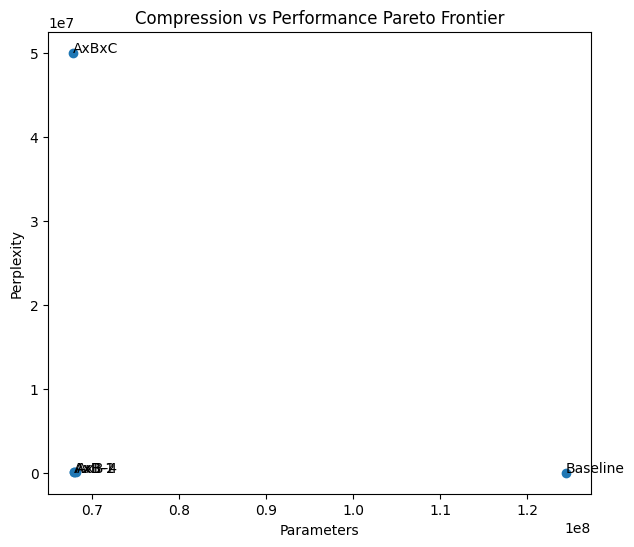

In [39]:
params = [baseline_params]
ppls = [baseline_ppl]

labels = ["Baseline"]

for r,ppl in zip(ranks,[x[2] for x in axb_results]):

    params.append(axb_results[ranks.index(r)][1])
    ppls.append(ppl)
    labels.append(f"AxB-{r}")

params.append(abc_params)
ppls.append(abc_ppl)
labels.append("AxBxC")

plt.figure(figsize=(7,6))

plt.scatter(params,ppls)

for i,label in enumerate(labels):
    plt.annotate(label,(params[i],ppls[i]))

plt.xlabel("Parameters")
plt.ylabel("Perplexity")

plt.title("Compression vs Performance Pareto Frontier")

plt.show()